In [1]:
import os, random
from pathlib import Path
from collections import defaultdict
from itertools import permutations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from simulation import*

c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
c:\Users\mahsh\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [32]:
df = pd.read_csv("election_table.csv")
election_table = pd.read_csv("election_table.csv")

directory = "np_data_new"
normalized_chunks_all, normalized_chunks_local = [], []
normalized_chunks_state, normalized_chunks_federal = [], []

normalized_chunks_partisan = []
normalized_chunks_non_partisan, normalized_chunks_primary = [], []

# ensure df has clean keys
df = df.copy()
df["filename"] = df["filename"].astype(str).str.strip()
df["level"]    = df["level"].astype(str).str.strip().str.upper()
level_map = df.set_index("filename")["level"].to_dict()

df2 = df.copy()
df2["filename"] = df2["filename"].astype(str).str.strip()
df2["partisan"]    = df2["partisan"].astype(str).str.strip().str.upper()
partisan_map = df2.set_index("filename")["partisan"].to_dict()

files = sorted(Path(directory).glob("*.npy"))
total_files = 0
for filename in os.listdir(directory):

    fpath = "np_data_new/"+filename
    filename = filename[:-4]+".csv"
    try: 
        candidates = election_table.loc[election_table["filename"]==filename, "candidates"].values[0]
        
    except Exception as e:
        continue
    
    if candidates <= 2:
        continue
    dist = normalize_data(np.load(fpath, allow_pickle=False))
    if dist.size == 0:
        continue
    normalized_chunks_all.append(dist)
    total_files += 1

    fname_csv = filename
    level = level_map.get(fname_csv)
    p = partisan_map.get(fname_csv)
    

    if level == "LOCAL":
        normalized_chunks_local.append(dist)
    elif level == "STATE":
      
        normalized_chunks_state.append(dist)
    elif level == "FEDERAL":
        normalized_chunks_federal.append(dist)
    
    if p == "YES":
        normalized_chunks_partisan.append(dist)
    elif p == "NO":
        normalized_chunks_non_partisan.append(dist)
    else:
        normalized_chunks_primary.append(dist)

all_dist     = np.concatenate(normalized_chunks_all)     if normalized_chunks_all     else np.array([], float)
local_dist   = np.concatenate(normalized_chunks_local)   if normalized_chunks_local   else np.array([], float)
state_dist   = np.concatenate(normalized_chunks_state)   if normalized_chunks_state   else np.array([], float)
federal_dist = np.concatenate(normalized_chunks_federal) if normalized_chunks_federal else np.array([], float)

partisan_dist   = np.concatenate(normalized_chunks_partisan)   if normalized_chunks_partisan   else np.array([], float)
non_partisan_dist   = np.concatenate(normalized_chunks_non_partisan)   if normalized_chunks_non_partisan   else np.array([], float)
primary_dist = np.concatenate(normalized_chunks_primary) if normalized_chunks_primary else np.array([], float)

print(f"Loaded {total_files} files → combined length: {all_dist.size}")
print(f"Loaded {total_files} primaryfiles → combined length: {primary_dist.size}")


Loaded 362 files → combined length: 12722034
Loaded 362 primaryfiles → combined length: 3198523


10058860


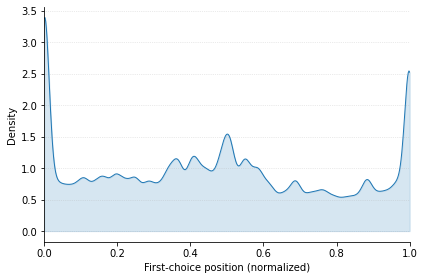

In [34]:
local_dist = np.asarray(local_dist, dtype=float)

print(local_dist.size)
if local_dist.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(local_dist)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    yp = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, yp, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, yp, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()

Inconsistent baloots' first-place choice

In [18]:
import os, pickle
import numpy as np
import pandas as pd

# --- CONFIG ---
directory = "dataverse_files_2025"                  # folder you iterate over
meta_table_path = "election_table.csv"              # must contain columns: filename, level

# load metadata and filter to STATE/FEDERAL
meta = pd.read_csv(meta_table_path, usecols=["filename", "level"])
meta["level"] = meta["level"].astype(str).str.strip().str.upper()
allowed = set(["LOCAL"])
keep_filenames = set(meta.loc[meta["level"].isin(allowed), "filename"].astype(str))

inconsistent_choices_local = []

for filename in os.listdir(directory):
    try:
        if filename not in keep_filenames:
            continue

        # 1) normalized_distances from null_elections/<filename>
        meta_path = os.path.join("null_elections", filename)
        df = pd.read_csv(meta_path, usecols=["candidate", "position"]).dropna(subset=["candidate", "position"])
        df["candidate"] = df["candidate"].astype(str).str.strip()

        # min–max normalize positions to [0,1]
        pmin, pmax = df["position"].min(), df["position"].max()
        den = pmax - pmin
        df["position_norm"] = (df["position"] - pmin) / den if den > 0 else 0.0

        # if duplicates exist, keep first row per candidate
        normalized_distances = (
            df.drop_duplicates("candidate", keep="first")
              .set_index("candidate")["position_norm"]
              .to_dict()
        )

        # 2) load ballots & candidates pickles
        stem = filename[:-4]
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_ballots.pkl"), "rb") as f:
            ballots = pickle.load(f)
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_candidates.pkl"), "rb") as f:
            candidates = pickle.load(f)

        # 3) collect first-choice positions for inconsistent ballots
        for b in ballots:
            if len(b) == 0:
                continue
            if not is_consistent(b, normalized_distances):
                # guard in case first-choice name not in dict
                first = b[0]
                if first in normalized_distances:
                    inconsistent_choices_local.append(float(normalized_distances[first]))

    except Exception as e:
        # optional: print or log the filename that failed
        # print(f"{filename} skipped due to: {e}")
        continue

# final array
inconsistent_choices_local = np.asarray(inconsistent_choices_local, dtype=float)
# print summary if you want
# print("Collected", inconsistent_choices.size, "inconsistent first-choice positions (STATE/FEDERAL).")




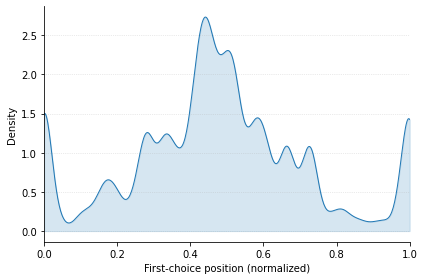

In [19]:
vals_local = np.asarray(inconsistent_choices_local, dtype=float)
vals_local = vals_local[np.isfinite(vals_local)]

if vals_local.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(vals_local)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    y_local = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y_local, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, y_local, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute KDE (need at least 2 finite values).")

In [20]:

meta = pd.read_csv(meta_table_path, usecols=["filename", "level"])
meta["level"] = meta["level"].astype(str).str.strip().str.upper()
allowed = set(["STATE"])
keep_filenames = set(meta.loc[meta["level"].isin(allowed), "filename"].astype(str))

inconsistent_choices_state = []

for filename in os.listdir(directory):
    try:
        if filename not in keep_filenames:
            continue

        # 1) normalized_distances from null_elections/<filename>
        meta_path = os.path.join("null_elections", filename)
        df = pd.read_csv(meta_path, usecols=["candidate", "position"]).dropna(subset=["candidate", "position"])
        df["candidate"] = df["candidate"].astype(str).str.strip()

        # min–max normalize positions to [0,1]
        pmin, pmax = df["position"].min(), df["position"].max()
        den = pmax - pmin
        df["position_norm"] = (df["position"] - pmin) / den if den > 0 else 0.0

        # if duplicates exist, keep first row per candidate
        normalized_distances = (
            df.drop_duplicates("candidate", keep="first")
              .set_index("candidate")["position_norm"]
              .to_dict()
        )

        # 2) load ballots & candidates pickles
        stem = filename[:-4]
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_ballots.pkl"), "rb") as f:
            ballots = pickle.load(f)
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_candidates.pkl"), "rb") as f:
            candidates = pickle.load(f)

        # 3) collect first-choice positions for inconsistent ballots
        for b in ballots:
            if len(b) == 0:
                continue
            if not is_consistent(b, normalized_distances):
                # guard in case first-choice name not in dict
                first = b[0]
                if first in normalized_distances:
                    inconsistent_choices_state.append(float(normalized_distances[first]))

    except Exception as e:
        # optional: print or log the filename that failed
        # print(f"{filename} skipped due to: {e}")
        continue

# final array
inconsistent_choices_state = np.asarray(inconsistent_choices_state, dtype=float)
# print summary if you want
# print("Collected", inconsistent_choices.size, "inconsistent first-choice positions (STATE/FEDERAL).")




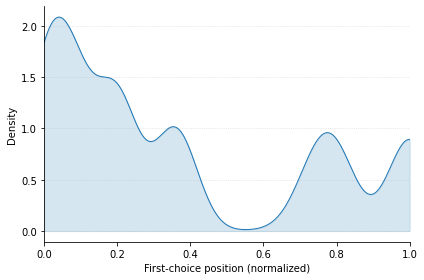

In [36]:
vals_state = np.asarray(inconsistent_choices_state, dtype=float)
vals_state = vals_state[np.isfinite(vals_state)]

if vals_state.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(vals_state)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    y_state = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y_state, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, y_state, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute KDE (need at least 2 finite values).")

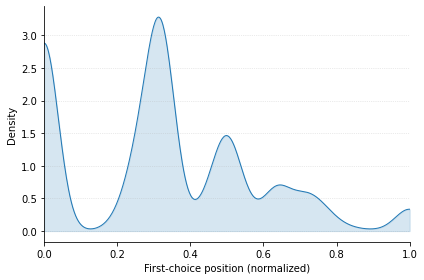

In [21]:

meta = pd.read_csv(meta_table_path, usecols=["filename", "level"])
meta["level"] = meta["level"].astype(str).str.strip().str.upper()
allowed = set(["FEDERAL"])
keep_filenames = set(meta.loc[meta["level"].isin(allowed), "filename"].astype(str))

inconsistent_choices_federal = []

for filename in os.listdir(directory):
    try:
        if filename not in keep_filenames:
            continue

        # 1) normalized_distances from null_elections/<filename>
        meta_path = os.path.join("null_elections", filename)
        df = pd.read_csv(meta_path, usecols=["candidate", "position"]).dropna(subset=["candidate", "position"])
        df["candidate"] = df["candidate"].astype(str).str.strip()

        # min–max normalize positions to [0,1]
        pmin, pmax = df["position"].min(), df["position"].max()
        den = pmax - pmin
        df["position_norm"] = (df["position"] - pmin) / den if den > 0 else 0.0

        # if duplicates exist, keep first row per candidate
        normalized_distances = (
            df.drop_duplicates("candidate", keep="first")
              .set_index("candidate")["position_norm"]
              .to_dict()
        )

        # 2) load ballots & candidates pickles
        stem = filename[:-4]
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_ballots.pkl"), "rb") as f:
            ballots = pickle.load(f)
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_candidates.pkl"), "rb") as f:
            candidates = pickle.load(f)

        # 3) collect first-choice positions for inconsistent ballots
        for b in ballots:
            if len(b) == 0:
                continue
            if not is_consistent(b, normalized_distances):
                # guard in case first-choice name not in dict
                first = b[0]
                if first in normalized_distances:
                    inconsistent_choices_federal.append(float(normalized_distances[first]))

    except Exception as e:
        # optional: print or log the filename that failed
        # print(f"{filename} skipped due to: {e}")
        continue

# final array
inconsistent_choices_federal = np.asarray(inconsistent_choices_federal, dtype=float)
# print summary if you want
# print("Collected", inconsistent_choices.size, "inconsistent first-choice positions (STATE/FEDERAL).")


vals_federal = np.asarray(inconsistent_choices_federal, dtype=float)
vals_federal = vals_federal[np.isfinite(vals_federal)]

if vals_federal.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(vals_federal)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    y_federal = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y_federal, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, y_federal, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute KDE (need at least 2 finite values).")

In [35]:
# ---- main function (expects voter_kde OR array; candidate_dist is (x, y)) ----
def top_n_gamma(n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, nl_dist, level, visualize=False):
    x_can, y_can = candidate_dist

    # sample candidate points proportional to candidate density
    probs = np.clip(np.asarray(y_can, float), 0, None)
    probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / probs.size
    k = min(10, x_can.size)
    replace = x_can.size < 10

    # gamma -> number of consistent voters (0..1000)
    df_gamma = pd.read_csv("election_table.csv")
    # choosing gamma from same candidate count and level
    mask = (
    df_gamma["candidates"].eq(n) &
    df_gamma["level"].astype(str).str.strip().str.upper().eq(level.strip().upper())
    )
    gamma_vals = df_gamma.loc[mask, "gamma"].to_numpy()

    random_gamma = float(np.random.choice(gamma_vals)) if gamma_vals.size else 0.5
    consistent_voters = int(np.clip(round(random_gamma * 1000), 0, 1000))


    candidate_points = np.random.choice(x_can, size=n, p=probs, replace=replace)
    candidate_points = np.array(list(dict.fromkeys(candidate_points.tolist())))  # de-dup, keep order
    

  
    top_n_points = candidate_points
    
    perms = generate_and_group_permutations(top_n_points, n)
    
    # round 2: consistent voters -> ranked by proximity
    sampled_points = sample_from(voter_dist, consistent_voters, 0.0, 1.0)
    median_voter = np.median(sampled_points)
    idx, median_voter_preference, dis = closest_value(top_n_points, median_voter)
    
    ballot_counts = {}
    for p in sampled_points:
        order = tuple(top_n_points[np.argsort(np.abs(top_n_points - p))])
        order = randomly_chop_order(order)
        ballot_counts[order] = ballot_counts.get(order, 0) + 1
    
    # inconsistent voters -> pick from "inconsistent" permutations bucketed by first choice
    
    for key in list(perms.keys()):
        try:
            # if you have is_consistent(), filter; else keep as-is
            perms[key] = [b for b in perms[key] if not is_consistent(b, {t: t for t in top_n_points})]
        except NameError:
            pass

    inc = 1000 - consistent_voters
    if inc > 0:
        inc_pts = sample_from(nl_dist, inc, 0.0, 1.0)
        for p in inc_pts:
            anchor = top_n_points[np.argmin(np.abs(top_n_points - p))]
            bag = perms.get(anchor) or []
            if bag:
                
                ranking = random.choice(bag)
                ballot_counts[ranking] = ballot_counts.get(ranking, 0) + 1

    # run election (assumes you have voting_rules implemented)
    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()
    plurality_winner = election.plurality()
    first_place_support = election.get_first_place()
    if condorcet_winner == -1:
        first_place_support[-1] = -1

    if visualize:
        plt.figure(figsize=(12,4))
        plt.plot(x_can, y_can, label='Candidate distribution')
        plt.scatter(candidate_points, np.zeros_like(candidate_points), label='Random candidates', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', s=100, label='Top N', zorder=6)
        plt.legend(); plt.xlabel('X'); plt.ylabel('Density'); plt.title('Candidate distribution'); plt.tight_layout(); plt.show()

       
    return (
        irv_winner, plurality_winner, condorcet_winner, top_n_points,
        random_gamma, median_voter, median_voter_preference,
        first_place_support.get(condorcet_winner, -1),
        first_place_support.get(irv_winner, -1),
        first_place_support.get(plurality_winner, -1),
    )





In [38]:
def top_n_gamma_bullet(
    n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, nl_dist, level,
    visualize=False, bullet_rate=0.35, rng=None
):
    rng = rng or np.random.default_rng()
    x_can, y_can = candidate_dist

    # --- helpers -------------------------------------------------------------
    def choose_bullet_indices(total, rate):
        if total <= 0:
            return set()
        cnt = int(np.round(total * rate))
        # guard bounds
        cnt = max(0, min(cnt, total))
        if cnt == 0:
            return set()
        return set(rng.choice(np.arange(total), size=cnt, replace=False))

    # --- sample candidates ---------------------------------------------------
    probs = np.clip(np.asarray(y_can, float), 0, None)
    probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / probs.size
    replace = x_can.size < 10

    # gamma -> number of consistent voters (0..1000)
    df_gamma = pd.read_csv("election_table.csv")
    mask = (
        df_gamma["candidates"].eq(n) &
        df_gamma["level"].astype(str).str.strip().str.upper().eq(level.strip().upper())
    )
    gamma_vals = df_gamma.loc[mask, "gamma"].to_numpy()
    random_gamma = float(np.random.choice(gamma_vals)) if gamma_vals.size else 0.5
    consistent_voters = int(np.clip(round(random_gamma * 1000), 0, 1000))

    candidate_points = np.random.choice(x_can, size=n, p=probs, replace=replace)
    candidate_points = np.array(list(dict.fromkeys(candidate_points.tolist())))  # de-dup, keep order
    top_n_points = candidate_points

    perms = generate_and_group_permutations(top_n_points, n)

    # round 2: consistent voters -> ranked by proximity
    sampled_points = sample_from(voter_dist, consistent_voters, 0.0, 1.0)
    median_voter = np.median(sampled_points)
    idx, median_voter_preference, dis = closest_value(top_n_points, median_voter)

    ballot_counts = {}

    # ------------------ ENFORCE 35% BULLETS (CONSISTENT) --------------------
    bullet_idx_cons = choose_bullet_indices(consistent_voters, bullet_rate)

    for i, p in enumerate(sampled_points):
        order_full = tuple(top_n_points[np.argsort(np.abs(top_n_points - p))])
        if i in bullet_idx_cons or n == 1:
            # bullet
            order = randomly_chop_order(order_full, min_len=1, rng=rng)
            # ensure bullet length is 1 even if RNG tried to pick >1
            if len(order) != 1:
                order = (order_full[0],)
        else:
            # non-bullet truncation: enforce len >= 2
            order = randomly_chop_order(order_full, min_len=min(2, len(order_full)), rng=rng)
        ballot_counts[order] = ballot_counts.get(order, 0) + 1

    # inconsistent voters -> pick from "inconsistent" permutations bucketed by first choice
    try:
        for key in list(perms.keys()):
            perms[key] = [b for b in perms[key] if not is_consistent(b, {t: t for t in top_n_points})]
    except NameError:
        pass

    inc = 1000 - consistent_voters
    if inc > 0:
        inc_pts = sample_from(nl_dist, inc, 0.0, 1.0)

        # ---------------- ENFORCE 35% BULLETS (INCONSISTENT) ----------------
        bullet_idx_inc = choose_bullet_indices(inc, bullet_rate)

        for j, p in enumerate(inc_pts):
            anchor = top_n_points[np.argmin(np.abs(top_n_points - p))]
            bag = perms.get(anchor) or []
            if bag:
                ranking_full = random.choice(bag)
            else:
                # fallback if no inconsistent permutations available
                ranking_full = tuple(top_n_points[np.argsort(np.abs(top_n_points - p))])

            if j in bullet_idx_inc or len(ranking_full) == 1:
                order = randomly_chop_order(ranking_full, min_len=1, rng=rng)
                if len(order) != 1:
                    order = (ranking_full[0],)
            else:
                order = randomly_chop_order(ranking_full, min_len=min(2, len(ranking_full)), rng=rng)

            ballot_counts[order] = ballot_counts.get(order, 0) + 1

    # run election (assumes you have voting_rules implemented)
    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()
    plurality_winner = election.plurality()
    first_place_support = election.get_first_place()
    if condorcet_winner == -1:
        first_place_support[-1] = -1

    if visualize:
        plt.figure(figsize=(12, 4))
        plt.plot(x_can, y_can, label='Candidate distribution')
        plt.scatter(candidate_points, np.zeros_like(candidate_points), label='Random candidates', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', s=100, label='Top N', zorder=6)
        plt.legend(); plt.xlabel('X'); plt.ylabel('Density'); plt.title('Candidate distribution')
        plt.tight_layout(); plt.show()

    return (
        irv_winner, plurality_winner, condorcet_winner, top_n_points,
        random_gamma, median_voter, median_voter_preference,
        first_place_support.get(condorcet_winner, -1),
        first_place_support.get(irv_winner, -1),
        first_place_support.get(plurality_winner, -1),
    )


number of simulated elections:  919


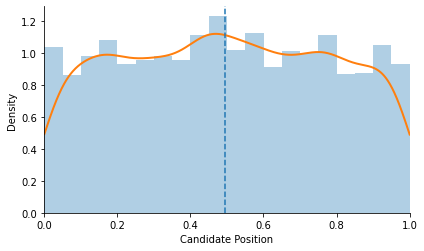

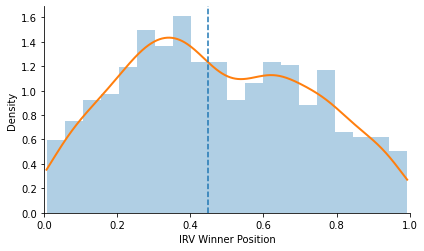

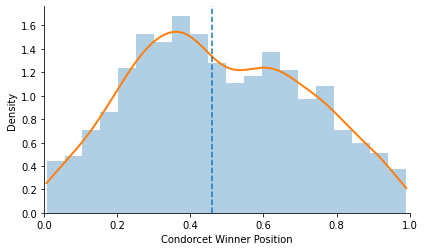

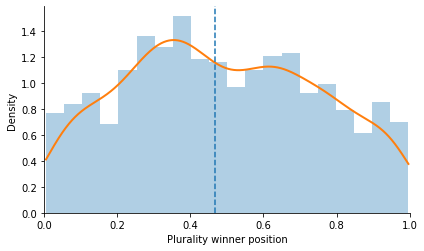

IRV vs Condorcet:  46
Plurality vs Condorcet:  109
IRV vs Plurality:  71
MVT Failure:  612


In [39]:
# N = 4, STATE
data = np.asarray(state_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


N_SIM = 1000
N_CANDIDATES = 4

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 
gamma_dist_state_3 = []

condorcet_failure = 0
median_voter_theorem_failure = 0
level = "STATE"

c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
    top_n_gamma_bullet(
        N_CANDIDATES,
        x_voter_plot=x_grid,
        y_voter_plot=y_grid,
        voter_dist=voter_kde,           # <-- KDE object so .resample works
        candidate_dist=candidate_dist,
        nl_dist = vals_state,
        level = level,
        visualize=False
    )

    gamma_dist_state_3.append(gamma)
    
    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)
gamma_dist_state_3 = np.asarray(gamma_dist_state_3, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print("IRV vs Condorcet: ", irv_condorcet_differences)
print("Plurality vs Condorcet: ", plurality_condorcet_differences)
print("IRV vs Plurality: ", irv_plurality_differences)
print("MVT Failure: ", median_voter_theorem_failure)

number of simulated elections:  991


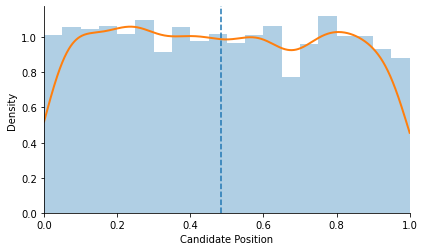

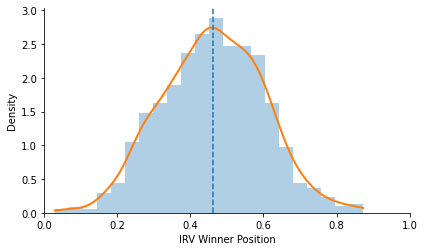

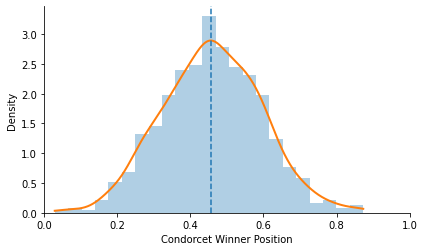

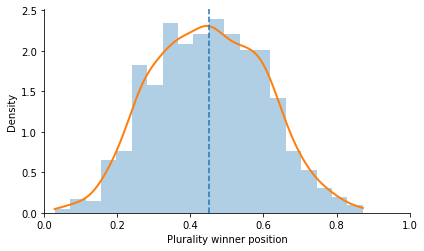

IRV vs Condorcet:  34
Plurality vs Condorcet:  140
IRV vs Plurality:  123
MVT Failure:  153


In [41]:
# N = 4, LOCAL
data = np.asarray(local_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


N_SIM = 1000
N_CANDIDATES = 4

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 
gamma_dist_state_3 = []

condorcet_failure = 0
median_voter_theorem_failure = 0
level = "LOCAL"

c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
    top_n_gamma_bullet(
        N_CANDIDATES,
        x_voter_plot=x_grid,
        y_voter_plot=y_grid,
        voter_dist=voter_kde,           # <-- KDE object so .resample works
        candidate_dist=candidate_dist,
        nl_dist = vals_local,
        level = level,
        visualize=False
    )

    gamma_dist_state_3.append(gamma)
    
    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)
gamma_dist_state_3 = np.asarray(gamma_dist_state_3, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print("IRV vs Condorcet: ", irv_condorcet_differences)
print("Plurality vs Condorcet: ", plurality_condorcet_differences)
print("IRV vs Plurality: ", irv_plurality_differences)
print("MVT Failure: ", median_voter_theorem_failure)

number of simulated elections:  959


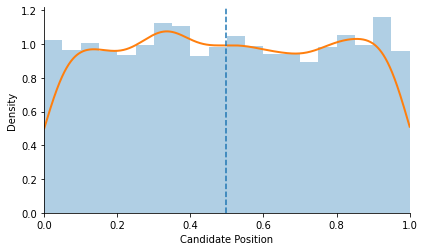

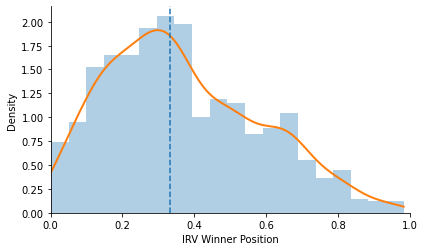

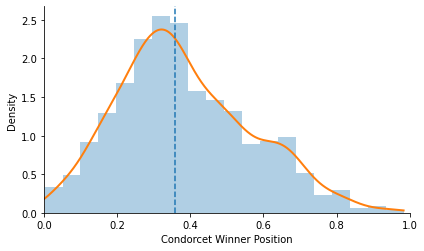

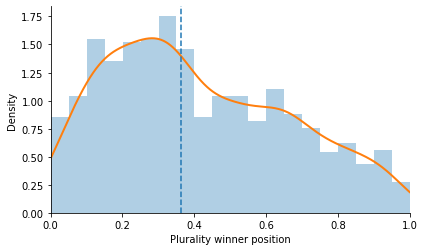

IRV vs Condorcet:  133
Plurality vs Condorcet:  238
IRV vs Plurality:  150
MVT Failure:  429


In [42]:
# N = 4, FEDERAL
data = np.asarray(federal_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


N_SIM = 1000
N_CANDIDATES = 4

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 
gamma_dist_state_3 = []

condorcet_failure = 0
median_voter_theorem_failure = 0
level = "FEDERAL"

c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
    top_n_gamma_bullet(
        N_CANDIDATES,
        x_voter_plot=x_grid,
        y_voter_plot=y_grid,
        voter_dist=voter_kde,           # <-- KDE object so .resample works
        candidate_dist=candidate_dist,
        nl_dist = vals_federal,
        level = level,
        visualize=False
    )

    gamma_dist_state_3.append(gamma)
    
    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)
gamma_dist_state_3 = np.asarray(gamma_dist_state_3, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print("IRV vs Condorcet: ", irv_condorcet_differences)
print("Plurality vs Condorcet: ", plurality_condorcet_differences)
print("IRV vs Plurality: ", irv_plurality_differences)
print("MVT Failure: ", median_voter_theorem_failure)